In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random

def get_column(data, index):
    return [row[index] for row in data]

def prepare_data(file_name_dataset):
    data = np.genfromtxt(file_name_dataset, delimiter=',', skip_header=1).tolist()
    N = len(data)
    tv_data = get_column(data, 0)
    radio_data = get_column(data, 1)
    newspaper_data = get_column(data, 2)
    sales_data = get_column(data, 3)
    X = [tv_data, radio_data, newspaper_data]
    y = sales_data
    return X, y

X, y = prepare_data('advertising.csv')
list = [sum(X[0][:5]), sum(X[1][:5]), sum(X[2][:5]), sum(y[:5])]
print(list)


[624.1, 175.1, 300.5, 78.9]


In [28]:
def initialize_params():
    # w1 = random.gauss(mu=0.0, sigma=0.01)
    # w2 = random.gauss(mu=0.0, sigma=0.01)
    # w3 = random.gauss(mu=0.0, sigma=0.01)
    # b = 0
    # return w1, w2, w3, b
    w1, w2, w3, b = (
        0.016992259082509283,
        0.0070783670518262355,
        -0.002307860847821344,
        0,
    )
    return w1, w2, w3, b

In [29]:
def predict(x1, x2, x3, w1, w2, w3, b):
    return x1 * w1 + x2 * w2 + x3 * w3 + b


y = predict(1, 1, 1, 0, 0.5, 0, 0.5)
print(y)

1.0


In [36]:
def compute_loss(y_hat, y):
    return (y_hat - y) ** 2

l = compute_loss(y_hat=1,y=0.5)
print(l)

0.25


In [31]:
def compute_gradient_wi(xi, y, y_hat):
    dl_dwi = 2 * xi * (y_hat - y)
    return dl_dwi

def compute_gradient_b(y, y_hat):
    return 2 * (y_hat - y)

g_wi = compute_gradient_wi(1,1,0.5)
print(g_wi)
g_b = compute_gradient_b(y=2.0, y_hat=0.5)
print(g_b)

-1.0
-3.0


In [32]:
def update_weight_wi(wi, dl_dwi, lr):
    wi = wi - lr * dl_dwi
    return wi

def update_weight_b(b, dl_db, lr):
    b = lr - lr * dl_db
    return b

In [33]:
def implement_linear_regression(X_data, y_data, epoch_max = 50, lr=1e-5):
    losses = []
    w1, w2, w3, b = initialize_params()
    N = len(y_data)
    for epoch in range(epoch_max):
        for i in range(N):
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]
            y = y_data[i]
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)
            loss = compute_loss(y, y_hat)
            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db = compute_gradient_b(y, y_hat)
            w1 = update_weight_wi(w1, dl_dw1, lr)
            w2 = update_weight_wi(w2, dl_dw2, lr)
            w3 = update_weight_wi(w3, dl_dw3, lr)
            b = update_weight_b(b, dl_db, lr)
            losses.append(loss)
    return (w1, w2, w3, b, losses)

In [34]:
X, y = prepare_data('advertising.csv')
(w1, w2, w3, b, losses) = implement_linear_regression(X, y)
print(w1, w2, w3)

0.07464850677421542 0.16066490202234038 0.01824366580568873


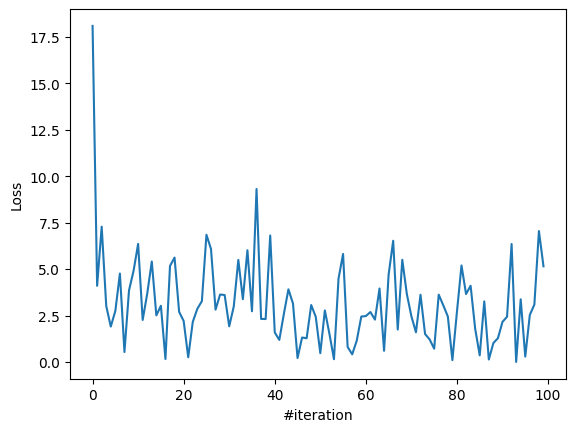

In [35]:
(w1, w2, w3, b, losses) = implement_linear_regression(X, y)
plt.plot(losses[:100])
plt.xlabel('#iteration')
plt.ylabel("Loss")
plt.show()

In [39]:
def implement_linear_regression_nsamples(X_data, y_data, epoch_max=50, lr=1e-5):
    losses = []
    w1, w2, w3, b = initialize_params()
    N = len(y_data)
    
    for epoch in range(epoch_max):
        loss_total = 0.0
        dw1_total = 0.0
        dw2_total = 0.0
        dw3_total = 0.0
        db_total = 0.0

        for i in range(N):
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]
            y = y_data[i]

            y_hat = predict(x1, x2, x3, w1, w2, w3, b)

            loss = compute_loss(y, y_hat)

            loss_total += loss

            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db = compute_gradient_b(y, y_hat)

            dw1_total += dl_dw1
            dw2_total += dl_dw2
            dw3_total += dl_dw3
            db_total += dl_db
        
        w1 -= lr * dw1_total / N
        w2 -= lr * dw2_total / N
        w3 -= lr * dw3_total / N
        
        losses.append(loss_total / N)
    
    return (w1, w2, w3, b, losses)
        

[172.98395547828923, 39.41112407199241, 18.1593331098737, 14.636132071438716, 13.915338341700705, 13.641551791095052, 13.442958281996598, 13.260744272512667, 13.085490028120727, 12.915574179972454, 12.75061011882211, 12.590410170893682, 12.43482202310813, 12.283702787196537, 12.136914786198336, 11.994324772411064, 11.855803690490118, 11.721226530144891, 11.590472196434778, 11.46342338619597, 11.339966468683166, 11.219991370021882, 11.103391461308432, 10.99006345023563, 10.87990727613243, 10.772826008309373, 10.66872574760604, 10.56751553103931, 10.469107239454926, 10.37341550808762, 10.280357639938288, 10.189853521879336, 10.101825543402242, 10.01619851792425, 9.932899606573374, 9.851858244373705, 9.773006068755416, 9.696276850316245, 9.621606425763394, 9.548932632967343, 9.478195248060835, 9.409335924518757, 9.34229813415645, 9.277027109985966, 9.213469790871816, 9.151574767929453, 9.091292232611602, 9.032573926429324, 8.975373092256152, 8.919644427165633, 8.865344036753793, 8.8124293

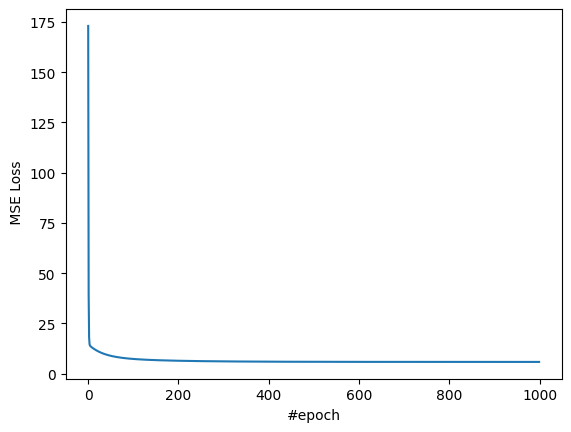

In [41]:
(w1, w2, w3, b, losses) = implement_linear_regression_nsamples(X, y, epoch_max=1000, lr=1e-5)
print(losses)
plt.plot(losses)
plt.xlabel('#epoch')
plt.ylabel(' MSE Loss')
plt.show()